## Deep Learning Model: Multi-Layer Perceptron (Keras)

In [33]:
# Cell: Imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [34]:
base_dir = Path.cwd()
dataset_path = base_dir / "dataset_final_incendies.parquet"

# Read only the needed months to reduce memory usage.
df = pd.read_parquet(
    dataset_path,
    filters=[("MOIS", ">=", 5), ("MOIS", "<=", 10)]
)

In [35]:
df.shape

(18201280, 59)

In [36]:
df.head()

,LAMBX,LAMBY,DATE,ANNEE,MOIS,JOUR,MOIS_NUM,T,FF,HU,...,SER,PENTEXP,ASPERITE,ACCES,INCID,NINCID,ANPYR,DPYR,DIST_MAILLE_M,INCENDIE
0,5400,20810,20150501,2015,5,1,5,12.6,5.8,98.7,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
1,5400,20810,20150502,2015,5,2,5,12.5,3.6,97.2,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
2,5400,20810,20150503,2015,5,3,5,16.1,2.7,88.6,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
3,5400,20810,20150504,2015,5,4,5,18.5,4.0,75.8,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0
4,5400,20810,20150505,2015,5,5,5,14.0,4.4,70.3,...,G11,NaN,NaN,NaN,0,0,NaN,NaN,631.084971,0


In [37]:
feux = df[df["INCENDIE"] == 1]
pas_feux = df[df["INCENDIE"] == 0].sample(n=len(feux) * 20, random_state=42)
df_reduit = pd.concat([feux, pas_feux]).sample(frac=1, random_state=42)

In [38]:
df_reduit.shape

(371721, 59)

In [39]:
VEGETATION_FEATURES = [
    "pct_resineux",             # share of coniferous trees (more flammable)
    "volume_total",             # total wood volume (fuel load proxy)
    "hauteur_moyenne",          # mean tree height
    "age_moyen",                # mean tree age
    "pct_mortalite",            # tree mortality rate
    "pct_probleme_sanitaire",   # share of trees with health issues
]

In [40]:
imputer = SimpleImputer(strategy="median")
df_reduit[VEGETATION_FEATURES] = imputer.fit_transform(df_reduit[VEGETATION_FEATURES])

In [41]:
target_col = "INCENDIE"

In [42]:
# Cell 1: Temporal split on the undersampled dataset + feature column setup
target_col = "INCENDIE"
feature_drop_cols = {target_col, "DATE", "DATEPOINT", "IDP"}
feature_cols = [col for col in df_reduit.columns if col not in feature_drop_cols]

train_df = df_reduit[df_reduit["ANNEE"] <= 2023].reset_index(drop=True)
test_df = df_reduit[df_reduit["ANNEE"] == 2024].reset_index(drop=True)

print("train_df (2015-2023):", train_df.shape, "| Fire:", train_df[target_col].sum())
print("test_df  (2024)     :", test_df.shape, "| Fire:", test_df[target_col].sum())

train_df (2015-2023): (335137, 59) | Fire: 16843
test_df  (2024)     : (36584, 59) | Fire: 858


In [43]:
# Cell 2: Prepare feature matrices and column lists
X_train = train_df[feature_cols].copy()
y_train = train_df[target_col].astype(int)
X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].astype(int)

numeric_features = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

print('Numeric features count:', len(numeric_features))
print('Categorical features count:', len(categorical_features))

Numeric features count: 46
Categorical features count: 9


## Preprocessing

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape :", X_test_processed.shape)

Processed train shape: (335137, 187)
Processed test shape : (36584, 187)


In [53]:
print("NaN restants train :", np.isnan(X_train_processed).sum())
print("NaN restants test  :", np.isnan(X_test_processed).sum())

NaN restants train : 294576
NaN restants test  : 28980


In [54]:
# Remplace chaque NaN par la mediane de sa colonne, calculee sur le train uniquement
medianes_train = np.nanmedian(X_train_processed, axis=0)

# Securite : si une colonne entiere est NaN, la mediane serait NaN aussi -> on met 0 dans ce cas
medianes_train = np.where(np.isnan(medianes_train), 0, medianes_train)

inds_train = np.where(np.isnan(X_train_processed))
X_train_processed[inds_train] = np.take(medianes_train, inds_train[1])

inds_test = np.where(np.isnan(X_test_processed))
X_test_processed[inds_test] = np.take(medianes_train, inds_test[1])

print("NaN restants train :", np.isnan(X_train_processed).sum())
print("NaN restants test  :", np.isnan(X_test_processed).sum())

NaN restants train : 0
NaN restants test  : 0


## Train / validation split

In [55]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_train
)
print(f"Train: {X_tr.shape[0]:,}  |  Val: {X_val.shape[0]:,}")

Train: 284,866  |  Val: 50,271


## Model architecture

In [56]:
n_features = X_train_processed.shape[1]

model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(name="auc"), keras.metrics.Precision(name="precision"), keras.metrics.Recall(name="recall")],
)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,145 (55.25 KB)

 Trainable params: 14,145 (55.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [57]:
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
class_weight = {0: 1.0, 1: neg / pos}
print("Class weights:", class_weight)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=5, restore_best_weights=True
)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1,
)

Class weights: {0: 1.0, 1: np.float64(18.89704547041978)}
Epoch 1/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step - auc: 0.8987 - loss: 0.7728 - precision: 0.1956 - recall: 0.8322 - val_auc: 0.9156 - val_loss: 0.3579 - val_precision: 0.1968 - val_recall: 0.8662
Epoch 2/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - auc: 0.9086 - loss: 0.7454 - precision: 0.1959 - recall: 0.8615 - val_auc: 0.9176 - val_loss: 0.3671 - val_precision: 0.1917 - val_recall: 0.8793
Epoch 3/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - auc: 0.9073 - loss: 0.7765 - precision: 0.1938 - recall: 0.8567 - val_auc: 0.9179 - val_loss: 0.3934 - val_precision: 0.1900 - val_recall: 0.8816
Epoch 4/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - auc: 0.9034 - loss: 0.8321 - precision: 0.1922 - recall: 0.8505 - val_auc: 0.9168 - val_loss: 0.4185 - val_precision: 0.1880 - val_recall: 0.8864
Epoch 5/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - auc: 0.8981 - loss: 0.9098 - precision: 0.1931 - recall: 0.8357 - val_auc: 0.9

## Training curves

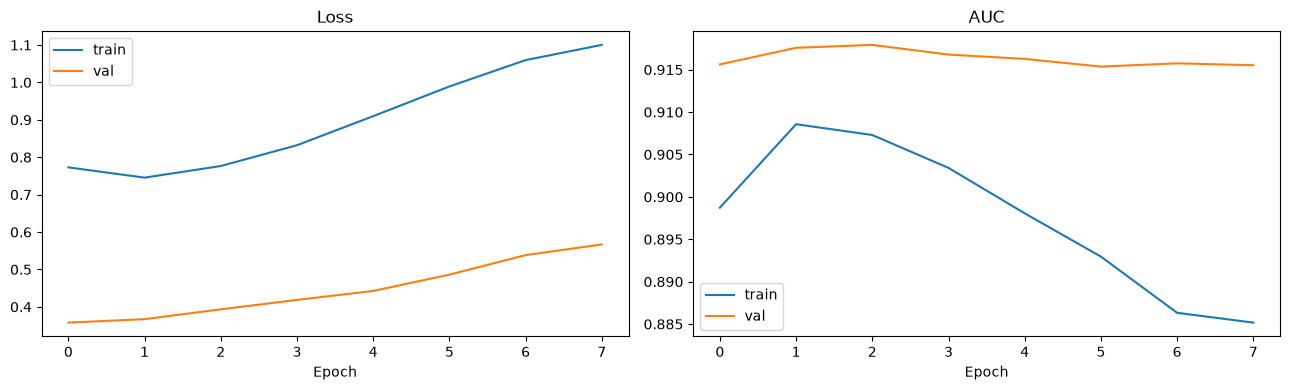

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["auc"], label="train")
axes[1].plot(history.history["val_auc"], label="val")
axes[1].set_title("AUC"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## Evaluation on the test set

In [59]:
DECISION_THRESHOLD = 0.3

y_proba_nn = model.predict(X_test_processed, verbose=0).ravel()
y_pred_nn = (y_proba_nn >= DECISION_THRESHOLD).astype(int)

roc_auc_nn = roc_auc_score(y_test, y_proba_nn)
avg_precision_nn = average_precision_score(y_test, y_proba_nn)

print(f"ROC-AUC           : {roc_auc_nn:.4f}")
print(f"Average Precision  : {avg_precision_nn:.4f}")
print(f"Decision threshold : {DECISION_THRESHOLD}")
print()
print(classification_report(y_test, y_pred_nn, target_names=["No fire", "Fire"]))

ROC-AUC           : 0.9285
Average Precision  : 0.3133
Decision threshold : 0.3

              precision    recall  f1-score   support

     No fire       1.00      0.86      0.92     35726
        Fire       0.13      0.86      0.22       858

    accuracy                           0.86     36584
   macro avg       0.56      0.86      0.57     36584
weighted avg       0.98      0.86      0.91     36584



## Visualizations

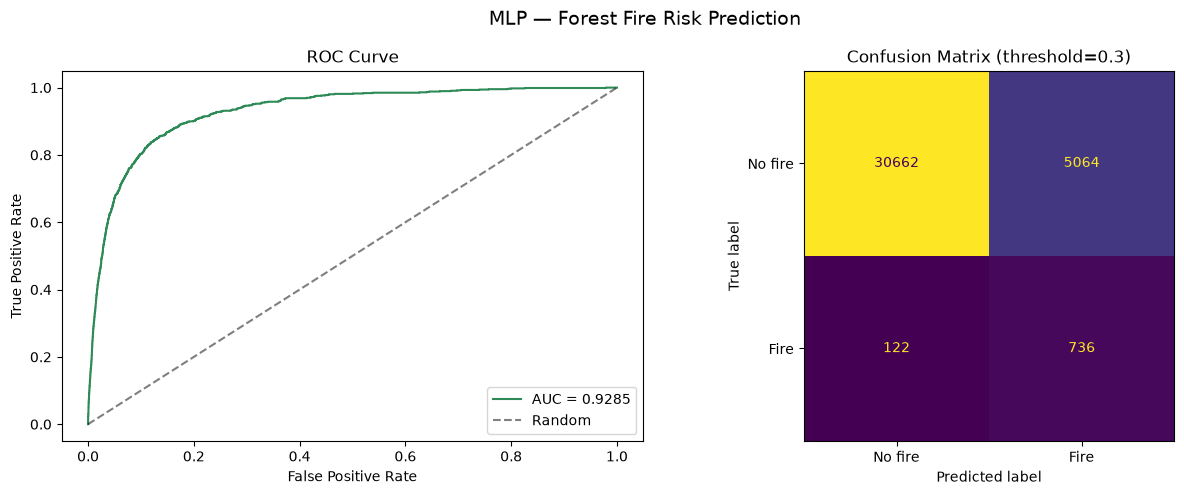

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("MLP — Forest Fire Risk Prediction", fontsize=14)

fpr, tpr, _ = roc_curve(y_test, y_proba_nn)
axes[0].plot(fpr, tpr, color="seagreen", label=f"AUC = {roc_auc_nn:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_nn, display_labels=["No fire", "Fire"], ax=axes[1], colorbar=False
)
axes[1].set_title(f"Confusion Matrix (threshold={DECISION_THRESHOLD})")

plt.tight_layout()
plt.show()

In [50]:
import numpy as np

print("NaN dans X_train_processed :", np.isnan(X_train_processed).sum())
print("Inf dans X_train_processed :", np.isinf(X_train_processed).sum())
finite_vals = X_train_processed[np.isfinite(X_train_processed)]
print("Valeur absolue max (finite):", np.abs(finite_vals).max())
print()
print("NaN dans X_test_processed  :", np.isnan(X_test_processed).sum())
print("Inf dans X_test_processed  :", np.isinf(X_test_processed).sum())

NaN dans X_train_processed : 294576
Inf dans X_train_processed : 0
Valeur absolue max (finite): 108.42653262884205

NaN dans X_test_processed  : 28980
Inf dans X_test_processed  : 0
